In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.neighbors import KernelDensity

In [47]:
def spin_dist_gen (N=1000): return np.random.uniform(0, 1, N)
def mass_dist_gen (mu = 1, sigma = 0.02, N = 1000): return np.random.normal(mu, sigma, N)
def f(X): return np.sqrt(1+np.sqrt(1-X**2)*0.5)

In [ ]:
M_dist = mass_dist_gen()
spin_dist = spin_dist_gen()

M_irr = M_dist * f(spin_dist)

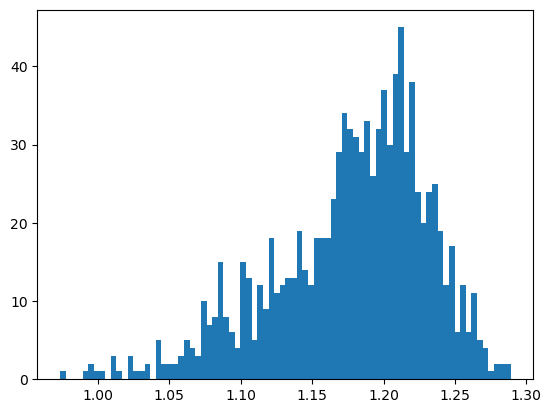

In [24]:
plt.hist (M_irr, bins = 80)
plt.show()

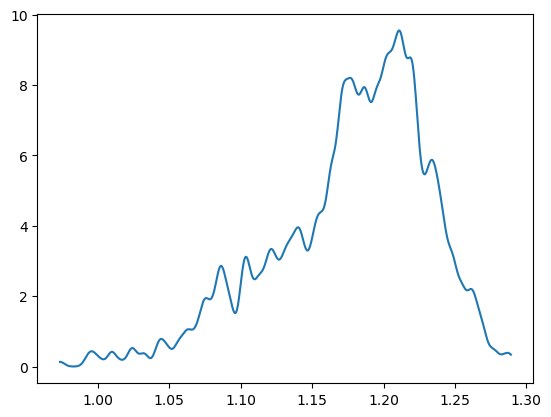

In [37]:
x = np.linspace (M_irr.min(),M_irr.max(),1000)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

KDEtophat = kde_sklearn(M_irr,bandwidth=0.003,kernel="gaussian")
plt.plot(x,KDEtophat)
plt.show()

In [60]:
f_sample = f(np.linspace (0, 1, 1000))

print (sp.stats.ks_2samp(M_irr, f_sample))

KstestResult(statistic=np.float64(0.506), pvalue=np.float64(7.2395025979917e-117), statistic_location=np.float64(1.224744871391589), statistic_sign=np.int8(-1))


In [62]:
sigma_range = np.linspace (0.01, 10, 1000)
KS_distances = np.zeros (len(sigma_range))

for i in range (len(sigma_range)):
    M_dist = M_dist = mass_dist_gen(sigma=sigma_range[i])
    M_irr = M_dist * f(spin_dist)

    x = np.linspace (M_irr.min(),M_irr.max(),1000)
    KDEtophat = kde_sklearn(M_irr,bandwidth=0.003,kernel="gaussian")
    KS_distances[i] = np.max(np.abs(M_irr, f_sample))

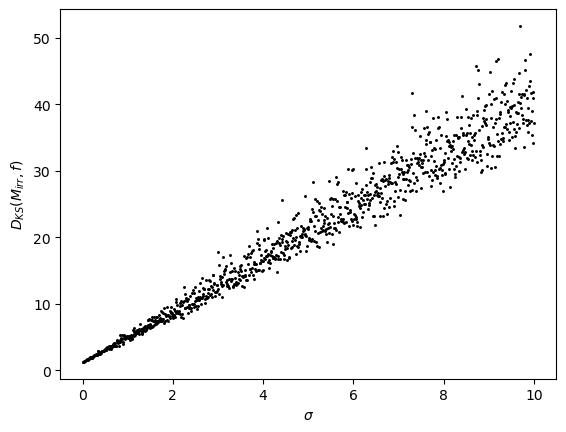

In [71]:
plt.scatter (sigma_range, KS_distances, marker='.', c='black', s=5)
plt.xlabel ('$\sigma$')
plt.ylabel ('$D_{KS} (M_{irr}, f)$')
plt.show()

In [72]:
KS_distances_2 = np.zeros (len(sigma_range))

for i in range (len(sigma_range)):
    M_dist = M_dist = mass_dist_gen(sigma=sigma_range[i])
    M_irr = M_dist * f(spin_dist)

    x = np.linspace (M_irr.min(),M_irr.max(),1000)
    KDEtophat = kde_sklearn(M_irr,bandwidth=0.003,kernel="gaussian")
    KS_distances_2[i] = np.max(np.abs(M_irr, M_dist))

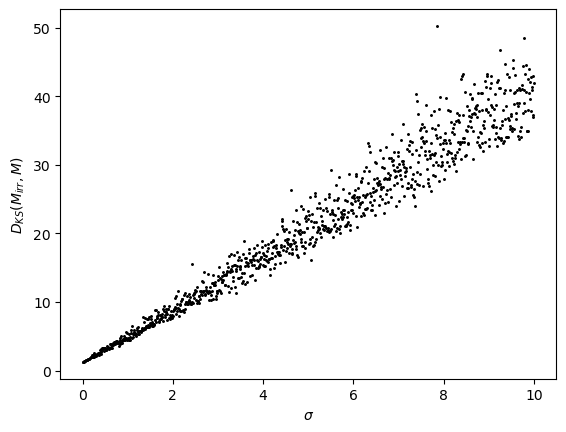

In [74]:
plt.scatter (sigma_range, KS_distances_2, marker='.', c='black', s=5)
plt.xlabel ('$\sigma$')
plt.ylabel ('$D_{KS} (M_{irr}, M)$')
plt.show()